In [1]:
from itertools import chain

import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
lineages = ("Endothelial", "Epithelial", "Immune", "Stroma")
HLCA_PATH = "/home/icb/vladimir.shitov/projects/2022_11_Schiller_lab_data_analysis/mapping_data_to_the_HLCA/data/HLCA_subset_lin_{lineage}_reannotated.h5ad"

In [3]:
adata = sc.concat([
    sc.read(HLCA_PATH.format(lineage=lineage))
    for lineage in lineages
])
adata

AnnData object with n_obs × n_vars = 922332 × 59574
    obs: "3'_or_5'", 'BMI', 'age', 'anatomical_region_ccf_score', 'ancestry', 'ann_coarse_for_GWAS_and_modeling', 'ann_finest_level', 'ann_level_1', 'ann_level_2', 'ann_level_3', 'ann_level_4', 'ann_level_5', 'assay', 'cause_of_death', 'cell_type', 'core_or_extension', 'dataset', 'development_stage', 'disease', 'donor_id', 'fresh_or_frozen', 'log10_total_counts', 'lung_condition', 'mixed_ancestry', 'organism', 'original_ann_level_1', 'original_ann_level_2', 'original_ann_level_3', 'original_ann_level_4', 'original_ann_level_5', 'original_ann_nonharmonized', 'reannotation_type', 'sample', 'scanvi_label', 'sequencing_platform', 'sex', 'smoking_status', 'study', 'subject_type', 'suspension_type', 'tissue', 'tissue_coarse_unharmonized', 'tissue_detailed_unharmonized', 'tissue_dissociation_protocol', 'tissue_level_2', 'tissue_level_3', 'tissue_sampling_method', 'total_counts', 'transf_ann_level_1_label', 'transf_ann_level_1_uncert', 'trans

In [4]:
adata.obs["reannotated_cell_types"].value_counts()

reannotated_cell_types
AM                     143740
Secretory               96228
Basal                   89746
AT2                     74300
SPP1+ Macrophages       74074
T cells                 71622
Ciliated                66782
IM                      38509
Fibroblasts             33959
DC                      29543
Monocytes               29026
NK cells                23127
gCap                    19662
ectopic EC              17671
SMC                     16371
B cells                 12533
Myofibroblasts          10911
Activated pericytes     10737
Mast cells              10397
AT1                      9295
arterial EC              8011
aCap                     7619
venous EC                7268
Plasma cells             6446
lymphatic EC             6362
Pericytes                3240
Aberrant Basaloid        2858
Mesothelial cells        1303
Rare                      992
Name: count, dtype: int64

In [5]:
# Epithelial cells
# √ AT1
# √ AT2
# √ Aberrant Basaloid / ADI (marker genes: KRT17, MMP7, CDH2, CDH3, PRSS2, LamC2, TP63, CDKN1A, CDKN2A, )
# √ Basal
# √ Ciliated
# √ Secretory

# Endothelial cells
# √ aCap
# √ gCap
# PLVAP+/VWA1+ EC (marker genes: PLVAP, VWA1, SERPINE1, COL15A1, COL4A1, COL4A2, ESM1)
# √ Arterial EC
# √ Venous EC
# √ Lymphatic EC

# Stromal cells
# √ Fibroblasts
# √ Myofibroblasts (marker genes: SPP1, CTHRC1, FAP, TNC, FN1, MMP9, PDPN)
# √ Pericytes
# √ Smooth Muscle cells
# √ Mesothelial cells

# Immune cells
## Mononuclear Phagocytes:
# √ Monocytes (classical/intermediate/non-classical)
# √ Macrophages (interstitial/alveolar/pro-fibrotic)
# X cDC1
# X cDC2
# X pDC
##  Lymphocytes:
# √ B cells
# √ Plasma cells
# √ T cells (Cd4/Cd8/Th1/Th2/Th17)
# √ NK cells
## Granulocytes:
# X Immature Neutrophils
# X Mature Neutrophils
# X Eosinophils
# X Basophils

# Others
# Megakaryocytes
# Erythrocytes


annotation_harmonization = {
    "AM": "Macrophages",
    "NK cells": "NK cells",
    "AT2": "AT2",
    "Basal": "Basal",
    "venous EC": "venous EC",
    "arterial EC": "arterial EC",
    "lymphatic EC": "lymphatic EC",
    "T cells": "T cells",
    "SPP1+ Macrophages": "SPP1+ Macrophages",
    "AT1": "AT1",
    "Secretory": "Secretory",
    "Ciliated": "Ciliated",

    "SMC": "SMC",
    "Monocytes": "Monocytes",
    "IM": "Macrophages",
    "ectopic EC": "VWA1+/PLVAP+ ectopic EC",
    "gCap": "capillary EC",
    "aCap": "capillary EC",
    "Rare": "Rare",
    "DC": "DC",
    "B cells": "B cells",
    "Plasma cells": "Plasma cells",
    "Mast cells": "Mast cells",
    "Aberrant Basaloid": "KRT17+/KRT5- Basaloid",
    "Fibroblasts": "Fibroblasts",
    "Myofibroblasts": "CTHRC1+ Myofibroblasts",
    "Pericytes": "Pericytes",
    "Mesothelial cells": "Mesothelial cells",
    "Activated pericytes": "Pericytes",
}

In [6]:
cell_type_order = [
    'AT1', 'AT2', 'KRT17+/KRT5- Basaloid', 'Basal', 'Ciliated', 'Secretory',
    'Fibroblasts', 'CTHRC1+ Myofibroblasts', 'Pericytes', 'SMC', 'Mesothelial cells',
    'capillary EC', 'arterial EC', 'venous EC', 'VWA1+/PLVAP+ ectopic EC',
    'lymphatic EC', 'Monocytes', 'Macrophages', 'SPP1+ Macrophages', 'DC', 'Mast cells',
    'B cells', 'Plasma cells', 'T cells', 'NK cells',
    # 'Rare',
]

In [7]:
new_cell_types = np.array(list(annotation_harmonization.values()))
not_found_cell_types = new_cell_types[~np.isin(new_cell_types, cell_type_order)]
not_found_cell_types

array(['Rare'], dtype='<U23')

In [8]:
adata.n_obs

922332

In [9]:
adata = adata[~adata.obs["reannotated_cell_types"].isin(not_found_cell_types), ]
adata.n_obs

921340

In [10]:
adata.obs["reannotated_cell_types"] = adata.obs["reannotated_cell_types"].map(annotation_harmonization)
adata.obs["reannotated_cell_types"].value_counts()

/localscratch/vladimir.shitov/ipykernel_4122124/1666639434.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["reannotated_cell_types"] = adata.obs["reannotated_cell_types"].map(annotation_harmonization)


reannotated_cell_types
Macrophages                182249
Secretory                   96228
Basal                       89746
AT2                         74300
SPP1+ Macrophages           74074
T cells                     71622
Ciliated                    66782
Fibroblasts                 33959
DC                          29543
Monocytes                   29026
capillary EC                27281
NK cells                    23127
VWA1+/PLVAP+ ectopic EC     17671
SMC                         16371
Pericytes                   13977
B cells                     12533
CTHRC1+ Myofibroblasts      10911
Mast cells                  10397
AT1                          9295
arterial EC                  8011
venous EC                    7268
Plasma cells                 6446
lymphatic EC                 6362
KRT17+/KRT5- Basaloid        2858
Mesothelial cells            1303
Name: count, dtype: int64

In [11]:
# Check that there are no missing values
adata.obs["reannotated_cell_types"].value_counts().sum()

921340

In [12]:
targets = {
    "Nintedanib" : ["FLT1", "KDR", "FLT4", "FGFR1", "FGFR2", "FGFR3", "FGFR4", "PDGFA", "PDGFB"],
    "GLPG1205" : ["GPR84"],
    "GLPG1690" : ["ENPP2"],
}

<Axes: ylabel='Count'>

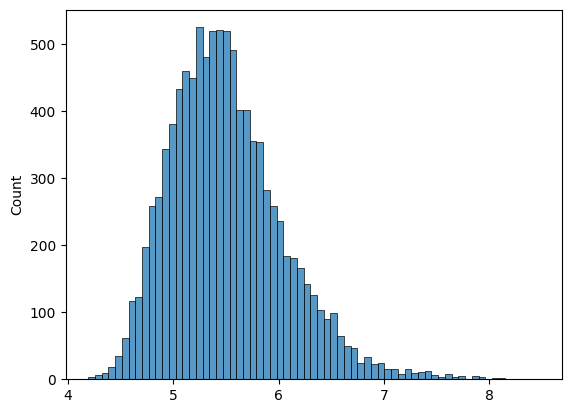

In [13]:
sns.histplot(adata.X[:10000, :].max(axis=1).toarray().flatten())

Check for granulocytes in HLCA annotation

In [14]:
for col in ("ann_level_1", "ann_level_2", "ann_level_3", "ann_level_4", "ann_level_5"):
    print(adata.obs[col].value_counts())
    print()

ann_level_1
Immune         438878
Epithelial     338524
Stroma          75946
Endothelial     66050
Unknown          1942
Name: count, dtype: int64

ann_level_2
Myeloid                     323725
Airway epithelium           246212
Lymphoid                    114074
Alveolar epithelium          84683
Blood vessels                59603
Fibroblast lineage           48744
Smooth muscle                19258
Unknown                      13151
Lymphatic EC                  6341
Submucosal Gland              4718
Mesothelium                    771
Hematopoietic stem cells        60
Name: count, dtype: int64

ann_level_3
Macrophages                     226259
Basal                            89222
Secretory                        88836
AT2                              75287
T cell lineage                   71969
Multiciliated lineage            66008
Unknown                          56783
Fibroblasts                      45210
Monocytes                        40769
EC capillary                 

Check disease-specificity of targets

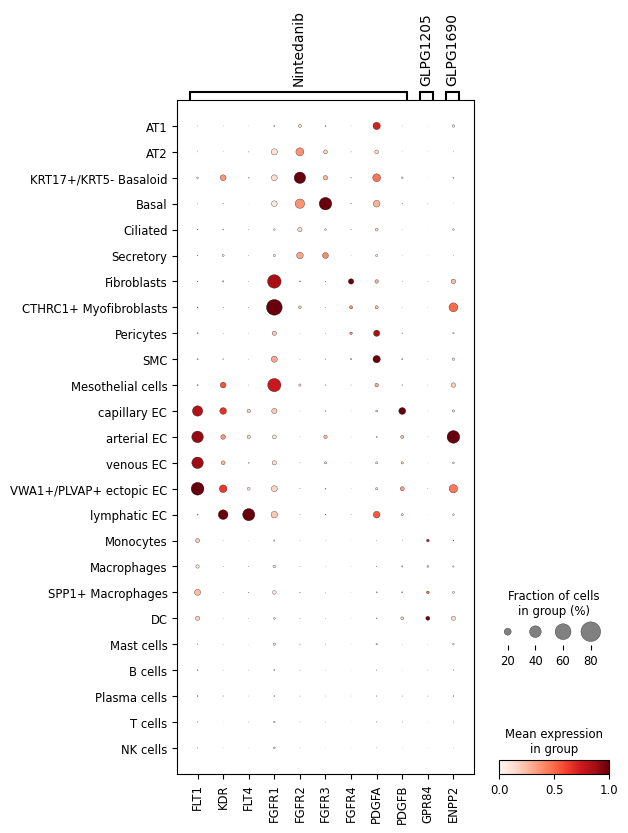

In [15]:
sc.pl.dotplot(
    adata,
    targets,
    groupby="reannotated_cell_types",
    standard_scale="var",
    dot_max=0.8, 
    categories_order=cell_type_order,
    save="drugs_targets_HLCA.pdf"
)

In [16]:
adata.obs["disease"]

GAATGAATCCTGCCAT-1-HCATisStab7747197                       normal
ACACTGAAGGATCGCA-1-HCATisStab7659971                       normal
GATGCTATCCTAAGTG-1-HCATisStab7747199                       normal
CTACGTCTCAAACGGG-1-HCATisStab7659971                       normal
CCACCTACAAGACGTG-1-HCATisStab7747199                       normal
                                                  ...            
AGCTCCTTCGCAAACT_SCD1_tsukui            interstitial lung disease
TCGGTAAAGCGTAATA_SCD2_tsukui            interstitial lung disease
AGCAGCCAGTACGCCC_IPF3_tsukui                   pulmonary fibrosis
TCAGCTCTCTAGCACA_IPF3_tsukui                   pulmonary fibrosis
GTCATTTTCTTAGAGC_IPF3_tsukui                   pulmonary fibrosis
Name: disease, Length: 921340, dtype: category
Categories (3, object): ['interstitial lung disease', 'normal', 'pulmonary fibrosis']

/home/icb/vladimir.shitov/software/miniconda3/envs/sample_representation_benchmark/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


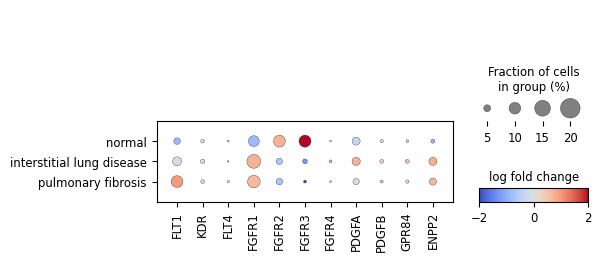

In [17]:
genes = list(chain(*targets.values()))

# mask = np.isin(adata.var_names, genes)
adata_subset = adata[:, genes]

sc.tl.rank_genes_groups(
    adata_subset, 
    groupby = 'disease',
    # mask_var = mask,
    method = 'wilcoxon',
    # reference="normal"
)

sc.pl.rank_genes_groups_dotplot(
    adata_subset,
    # groupby='disease',
    var_names = genes, 
    values_to_plot='logfoldchanges',
    dot_max = 0.2,
    vmax=2,
    vmin=-2,
    cmap = 'coolwarm',
    dendrogram = False,
    categories_order=['normal', 'interstitial lung disease', 'pulmonary fibrosis'],
    save = 'disease_specificity_HLCA.pdf'
)

/localscratch/vladimir.shitov/ipykernel_4122124/2590362283.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_subset.obs["disease"] = adata.obs["disease"].map({"interstitial lung disease": "Disease", "pulmonary fibrosis": "Disease", "normal": "Normal"})


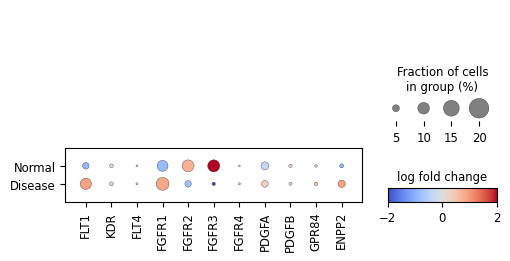

In [18]:
genes = list(chain(*targets.values()))

# mask = np.isin(adata.var_names, genes)
adata_subset = adata[:, genes]
adata_subset.obs["disease"] = adata.obs["disease"].map({"interstitial lung disease": "Disease", "pulmonary fibrosis": "Disease", "normal": "Normal"})

sc.tl.rank_genes_groups(
    adata_subset, 
    groupby = 'disease',
    # mask_var = mask,
    method = 'wilcoxon',
    # reference="normal"
)

sc.pl.rank_genes_groups_dotplot(
    adata_subset,
    # groupby='disease',
    var_names = genes, 
    values_to_plot='logfoldchanges',
    dot_max = 0.2,
    vmax=2,
    vmin=-2,
    cmap = 'coolwarm',
    dendrogram = False,
    categories_order=["Normal", "Disease"],
    save = 'disease_specificity_grouped_HLCA.pdf'
)

# Checking LPA receptors

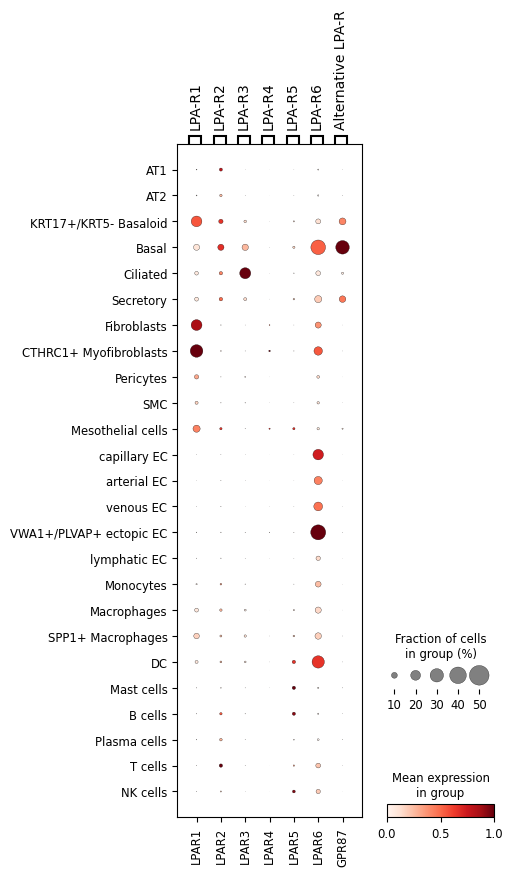

In [19]:
lpa_receptors = {
    'LPA-R1' : ['LPAR1'],
    'LPA-R2' : ['LPAR2'],
    'LPA-R3' : ['LPAR3'],
    'LPA-R4' : ['LPAR4'],
    'LPA-R5' : ['LPAR5'],
    'LPA-R6' : ['LPAR6'],
    'Alternative LPA-R' : ['GPR87']
}
 

sc.pl.dotplot(
    adata,
    var_names=lpa_receptors, 
    groupby="reannotated_cell_types",
    categories_order=cell_type_order,
    standard_scale="var",
    dot_max=0.5,
    cmap="Reds",
    save="lpa_receptors.pdf"
)